In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("/content/StudentsPerformance.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 303.7 KB


In [ ]:
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.select_dtypes(include=['number']).describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
high_math = df[df['math score'] > 90].head()
high_math

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
34,male,group E,some college,standard,none,97,87,82
104,male,group C,some college,standard,completed,98,86,90
114,female,group E,bachelor's degree,standard,completed,99,100,100
121,male,group B,associate's degree,standard,completed,91,89,92
149,male,group E,associate's degree,free/reduced,completed,100,100,93


In [ ]:
failed_math = df[df['math score'] < 40].head()
failed_math

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
9,female,group B,high school,free/reduced,none,38,60,50
17,female,group B,some high school,free/reduced,none,18,32,28
55,female,group C,high school,free/reduced,none,33,41,43
59,female,group C,some high school,free/reduced,none,0,17,10
61,male,group A,some high school,free/reduced,none,39,39,34


In [ ]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [ ]:
def performance_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 50:
        return "Pass"

    else:
        return "Fail"

df['performance'] = df['average_score'].apply(performance_category)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Fail
4,male,group C,some college,standard,none,76,78,75,76.333333,Pass


In [ ]:
df['math score'].value_counts().sort_index()

,count
math score,
0,1
8,1
18,1
19,1
22,1
...,...
96,3
97,6
98,3


In [ ]:
df['performance'].value_counts()

,count
performance,
Pass,699
Excellent,198
Fail,103


In [ ]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [ ]:
df.groupby('gender')['average_score'].mean()

,average_score
gender,
female,69.569498
male,65.837483


In [ ]:
df.groupby('parental level of education')['average_score'].mean()

,average_score
parental level of education,
associate's degree,69.569069
bachelor's degree,71.923729
high school,63.096939
master's degree,73.598870
some college,68.476401
some high school,65.108007


In [ ]:
df.groupby('gender')['performance'].value_counts()

gender  performance
female  Pass           361
        Excellent      118
        Fail            39
male    Pass           338
        Excellent       80
        Fail            64
Name: count, dtype: int64

In [ ]:
df.sort_values(by='average_score', ascending=False).head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000,Excellent
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,Excellent
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,Excellent
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,Excellent
712,female,group D,some college,standard,none,98,100,99,99.000000,Excellent


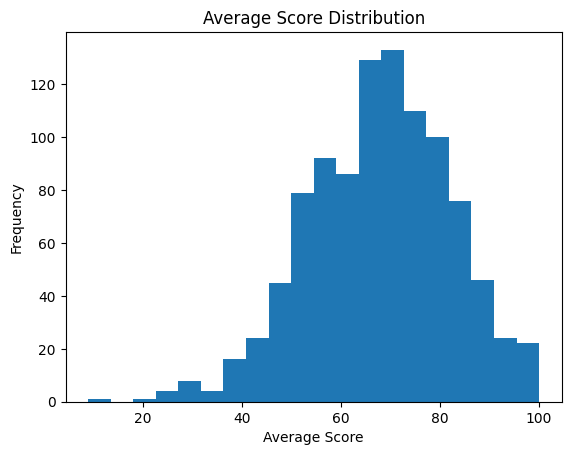

In [ ]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

plt.hist(df['average_score'], bins=20)

plt.title("Average Score Distribution")
plt.xlabel("Average Score")
plt.ylabel("Frequency")

plt.show()

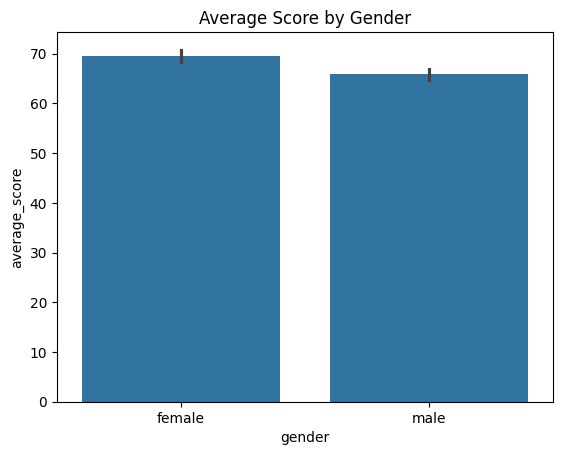

In [ ]:
sns.barplot(
    x='gender',
    y='average_score',
    data=df
)

plt.title("Average Score by Gender")

plt.show()

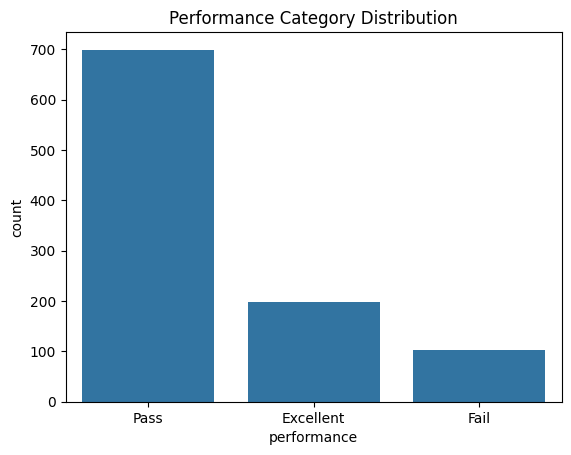

In [ ]:
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"

df['performance'] = df['average_score'].apply(performance_category)

sns.countplot(
    x='performance',
    data=df
)

plt.title("Performance Category Distribution")
plt.show()

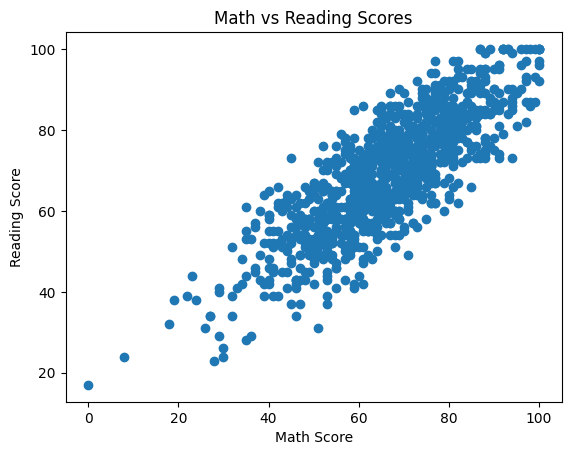

In [ ]:
plt.scatter(
    df['math score'],
    df['reading score']
)

plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.title("Math vs Reading Scores")

plt.show()

In [ ]:
pivot = df.pivot_table(
    values='average_score',
    index='gender',
    columns='performance',
    aggfunc='mean'
)

pivot

performance,Excellent,Fail,Pass
gender,,,
female,88.002825,39.350427,66.808864
male,85.679167,43.723958,65.328402


In [ ]:
df.corr(numeric_only=True)

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


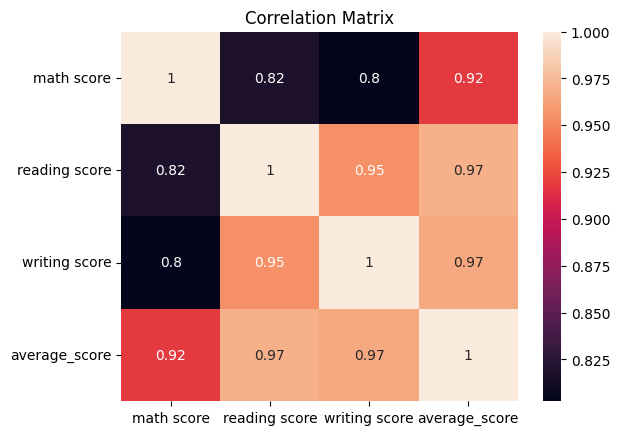

In [ ]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
df.to_csv("processed_student_data.csv", index=False)

In [ ]:
excellent_students = df[df['performance'] == "Excellent"]
excellent_students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
6,female,group B,some college,standard,completed,88,95,92,91.666667,Excellent
16,male,group C,high school,standard,none,88,89,86,87.666667,Excellent
34,male,group E,some college,standard,none,97,87,82,88.666667,Excellent


In [ ]:
fail_students = df[df['performance'] == "Fail"]
fail_students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Fail
7,male,group B,some college,free/reduced,none,40,43,39,40.666667,Fail
9,female,group B,high school,free/reduced,none,38,60,50,49.333333,Fail
11,male,group D,associate's degree,standard,none,40,52,43,45.000000,Fail
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000,Fail


In [ ]:
df.groupby('performance')['average_score'].describe()

,count,mean,std,min,25%,50%,75%,max
performance,,,,,,,,
Excellent,198.0,87.063973,5.266325,80.0,82.750000,86.000000,90.25,100.000000
Fail,103.0,42.067961,7.728137,9.0,39.166667,44.666667,48.00,49.666667
Pass,699.0,66.092990,8.275219,50.0,59.333333,67.000000,73.00,79.666667


In [1]:
import json
import sqlite3

In [6]:
json_sample = """
[
  {"name": "Student1", "average_score": 88, "performance": "Excellent"},
  {"name": "Student2", "average_score": 55, "performance": "Pass"},
  {"name": "Student3", "average_score": 35, "performance": "Fail"}
]
"""

json_data = pd.read_json(json_sample)

json_data


/tmp/ipython-input-4268563147.py:9: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  json_data = pd.read_json(json_sample)


,name,average_score,performance
0,Student1,88,Excellent
1,Student2,55,Pass
2,Student3,35,Fail


In [9]:
import os
import sqlite3

mini_students = pd.DataFrame({
    "student_id": [1, 2, 3],
    "math_score": [85, 60, 40],
    "reading_score": [90, 70, 50]
})

mini_students

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

conn = sqlite3.connect("data/demo.db")
mini_students.to_sql("systems", conn, if_exists="replace", index=False)
df_sql = pd.read_sql("SELECT * FROM systems", conn)
conn.close()
df_sql

,student_id,math_score,reading_score
0,1,85,90
1,2,60,70
2,3,40,50


In [11]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"

df['performance'] = df['average_score'].apply(performance_category)

simplifiedDF = df[[
    "gender",
    "race/ethnicity",
    "parental level of education",
    "math score",
    "reading score",
    "writing score",
    "average_score",
    "performance"
]].copy()

simplifiedDF.head()

,gender,race/ethnicity,parental level of education,math score,reading score,writing score,average_score,performance
0,female,group B,bachelor's degree,72,72,74,72.666667,Pass
1,female,group C,some college,69,90,88,82.333333,Excellent
2,female,group B,master's degree,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,47,57,44,49.333333,Fail
4,male,group C,some college,76,78,75,76.333333,Pass


In [12]:
simplifiedDF.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
math score,0
reading score,0
writing score,0
average_score,0
performance,0


In [13]:
q1= simplifiedDF["average_score"].quantile(0.01)
q99= simplifiedDF["average_score"].quantile(0.99)
simplifiedDF["average_score"]= simplifiedDF["average_score"].clip(q1,q99)

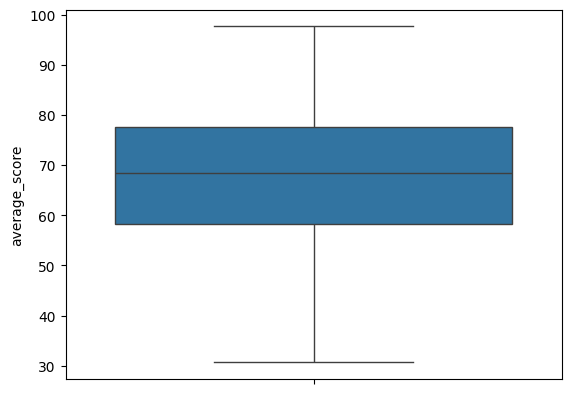

In [14]:
sns.boxplot(data=simplifiedDF, y="average_score")
plt.show()

In [15]:
pivot_table = simplifiedDF.pivot_table(
    values="average_score",
    index="parental level of education",
    columns="performance",
    aggfunc="mean",
    fill_value=0
)

pivot_table

performance,Excellent,Fail,Pass
parental level of education,,,
associate's degree,87.483660,44.803922,66.354978
bachelor's degree,89.301075,44.750000,67.759494
high school,84.366667,42.807475,64.953380
master's degree,88.750000,44.666667,66.385965
some college,86.702899,39.576444,66.062626
some high school,84.811111,42.228966,65.966667


In [16]:
corr_matrix = simplifiedDF.corr(numeric_only=True)
corr_matrix

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.915792
reading score,0.817580,1.000000,0.954598,0.969463
writing score,0.802642,0.954598,1.000000,0.964128
average_score,0.915792,0.969463,0.964128,1.000000


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (X) → independent variables
x = df[["math score", "reading score", "writing score"]]

# Target (Y) → dependent variable
y = df[["average_score"]]

# Split into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

# Create model
lin_model = LinearRegression()
# Train model
lin_model.fit(x_train, y_train)
# Calculate R² score
r2_score = lin_model.score(x_test, y_test)

print(r2_score)


1.0


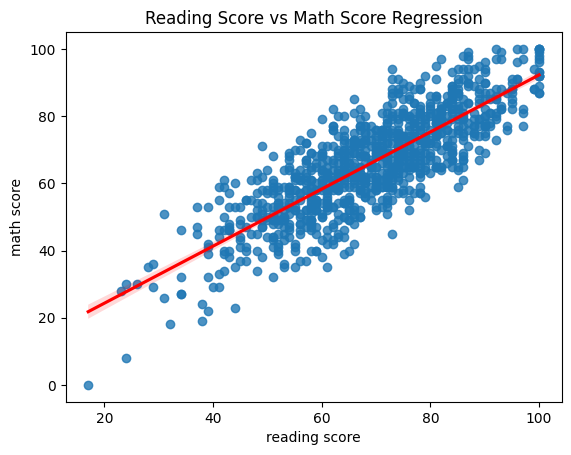

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x="reading score",
    y="math score",
    line_kws={"color": "red"}
)

plt.title("Reading Score vs Math Score Regression")
plt.show()